# HOMEWORK TWO BRAEDEN CULLEN

# 1a

As the input current is varried, we see an increased number of spikes fired by the neuron. With 0 nA of input current (no input current), the membrate relaxes to the resting phase which is -70 mv. When we leverage 1 nA of input current, the streaty state rises to -60 mv but we still do not see any spiking because we are still not at the critical threshold. When we increase the input current all the way up to 10 nA, the neuron is driven over -54mv which causes regular spikes! 37 to be exact over the time interval. Each spike involves going thru the full action potental, reset, and recovery preemting the next spike!

****************************************

injected current = 0


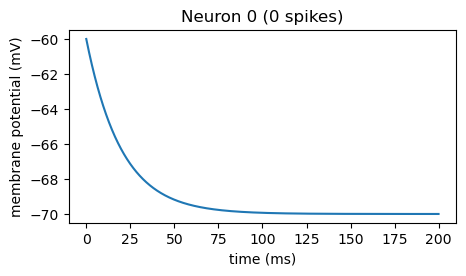

****************************************
****************************************

injected current = 1


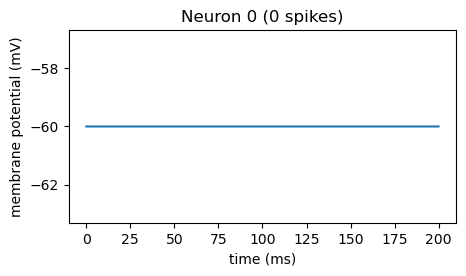

****************************************
****************************************

injected current = 10


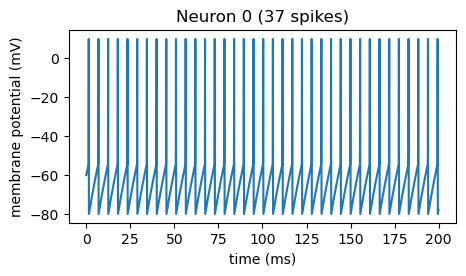

****************************************


In [2]:
from nsimulator import nsimulator
import numpy as np
import matplotlib.pyplot as plt

n_neurons = 1
record_time = 0.2 
initial_potential = -60  

currents_nA = [0, 1, 10]

for I_e in currents_nA:
    print(f"****************************************")
    print(f"\ninjected current = {I_e}")
    sim = nsimulator(n_neurons)
    sim.set_mpotential(0, initial_potential) # set membrane potential
    sim.set_Ie(0, I_e) # set initial current
    sim.simulate_timeinterval(0.0, record_time)
    sim.plot_membranepotentials([0]) # plot recorded membane potential
    print(f"****************************************")

# 1b

With input current 0nA, both experiments (-80 mv and 0mv initial membrame potential) relax to the resting phase -70mv. The only difference is that in the -80mv experiment the path rises upward from -80 versus with 0mv the path decays down from 0. The threshold is not met (-54) and therefore, no spiking occurs. There is no spiking in the -80mv instance when 0nA is injected, and a single spike in the 0mv instance. In the 0mv injection instance (for 0nA) there is a single transient spike b/c it is initialzied above the -54 threshold but since we initialize input current with 0 it relaxes back down.

With input current 1nA, 0mv intial membrane potential exhibits one spike and approaches -60mv whereas -80mv initial membrane potentail exhibits no spikes and approaches -60mv. Again, we see that single transient spike due to starting input current above the threshod, but again we hit convergence on the same steady state of -60mv for both experiments.

With input current 10nA, both experiments have frequent spiking. The 0mv initial membrane potential experiment exhibits 37 spikes and the -80mv initial membrane potential exhibits 36 spikes because former yeilds a shorter first spike latency. After that first spike, spiking becomes periodic and they both have essentially the same steady firing rate after that first initialization.



****************************************

injected current = 0


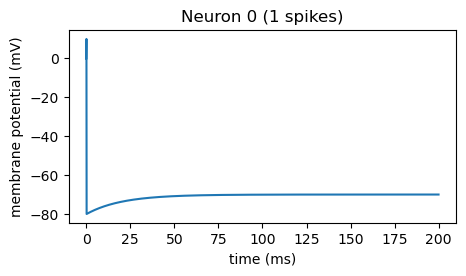

****************************************
****************************************

injected current = 1


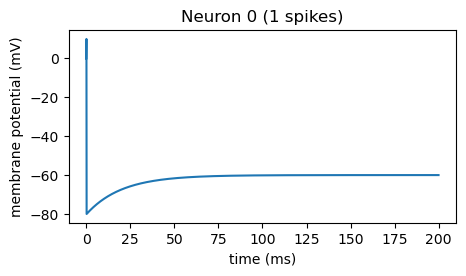

****************************************
****************************************

injected current = 10


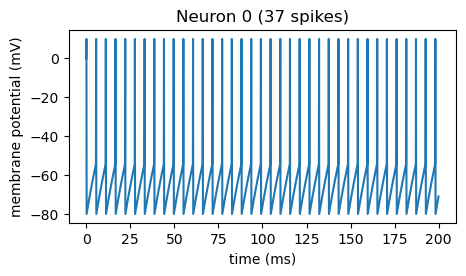

****************************************


In [3]:

n_neurons = 1
record_time = 0.2 

currents_nA = [0, 1, 10]


for I_e in currents_nA:
    print(f"****************************************")
    print(f"\ninjected current = {I_e}")
    sim = nsimulator(n_neurons)
    sim.set_mpotential(0, 0) # set membrane potential
    sim.set_Ie(0, I_e) # set initial current
    sim.simulate_timeinterval(0.0, record_time)
    sim.plot_membranepotentials([0]) # plot recorded membane potential
    print(f"****************************************")


****************************************

injected current = 0


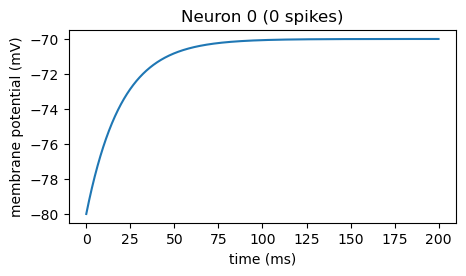

****************************************
****************************************

injected current = 1


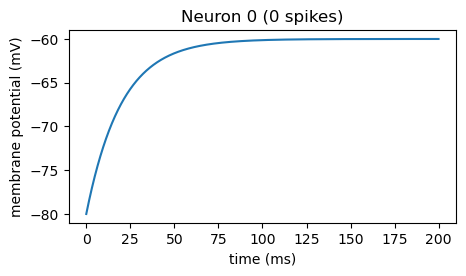

****************************************
****************************************

injected current = 10


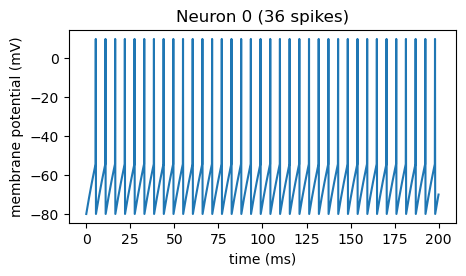

****************************************


In [4]:
n_neurons = 1
record_time = 0.2 
initial_potential = -80  

currents_nA = [0, 1, 10]

for I_e in currents_nA:
    print(f"****************************************")
    print(f"\ninjected current = {I_e}")
    sim = nsimulator(n_neurons)
    sim.set_mpotential(0, initial_potential) # set membrane potential
    sim.set_Ie(0, I_e) # set initial current
    sim.simulate_timeinterval(0.0, record_time)
    sim.plot_membranepotentials([0]) # plot recorded membane potential
    print(f"****************************************")

# 1c

Neuron ones inhibitory synapse hyperpolarizes the second neuron in short pulses (synchronized to the first neurons spikes). This effectively delays neuron two's spikes when it is close to or above the threshold and stabilizes below it. This effectively causes a lower firing rate for neuron two compared to same single neuron case.


****************************************

injected current = 0


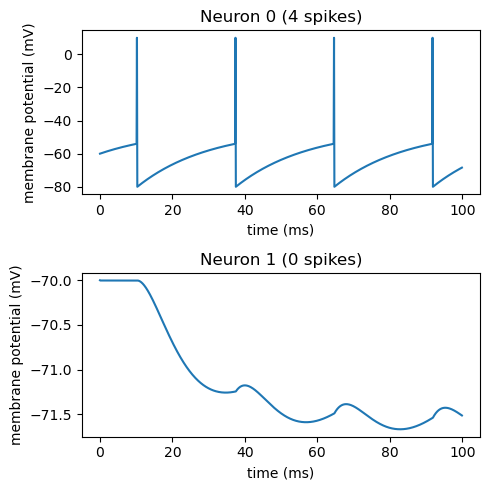

****************************************
****************************************

injected current = 1


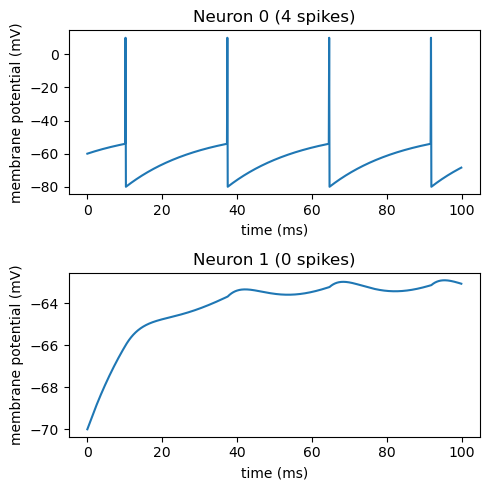

****************************************
****************************************

injected current = 3


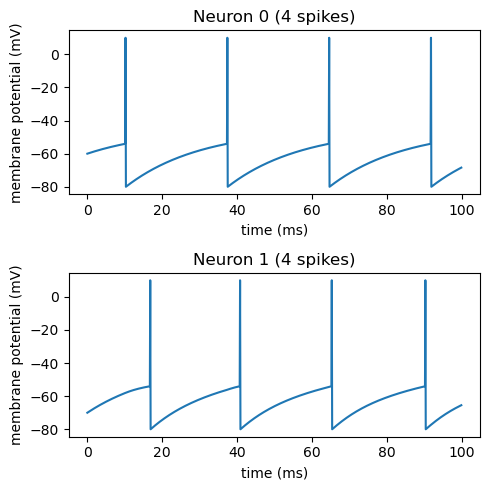

****************************************
****************************************

injected current = 6


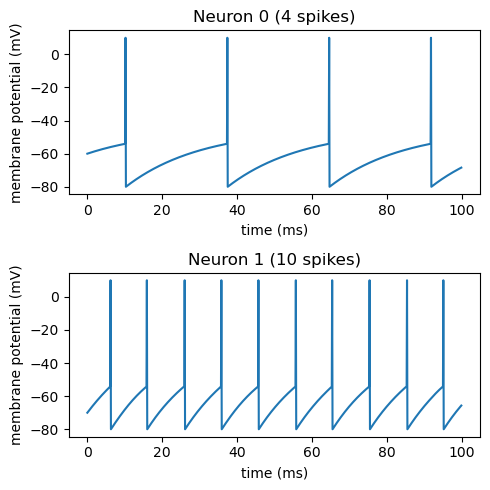

****************************************
****************************************

injected current = 10


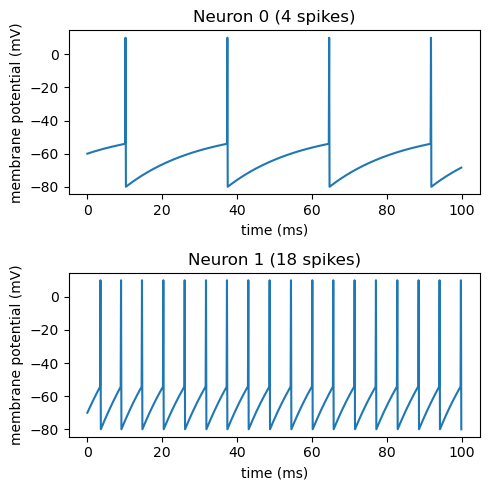

****************************************


In [5]:

record_time = 0.1  # seconds
I_e_1 = 2.5          # nA into Neuron 1 (always)
volt_1 = -60            # mV initial Vm for Neuron 1
volt_2 = -70         # mV initial Vm for Neuron 2

for I_e_2 in [0, 1, 3, 6, 10]:
    print(f"****************************************")
    print(f"\ninjected current = {I_e_2}")
    sim = nsimulator(2)
    # init membrane potentials
    sim.set_mpotential(0, volt_1)  
    sim.set_mpotential(1, volt_2)  
    # inject currents
    sim.set_Ie(0, I_e_1)  
    sim.set_Ie(1, I_e_2)  
    # make connection
    # neuron 1 inhibits neuron 2
    sim.make_inhibitory_connection(0, 1)
    #stimulate
    sim.simulate_timeinterval(0.0, record_time)
    sim.plot_membranepotentials([0, 1])
    print(f"****************************************")

# 1d

The first neurons' excititory synapse depolarizes neuron two with short upward bumps in voltage which are synchronized to the first neurons' spikes. This in effect increases neuron twos excitability which lowers first spike latency and increases the firing rate. Additionally, it could potentially produce spikes in situations where the first neuron would typically lay dormant. Furthermore, the spikes from the first neuron promote synchronization with neuron two's spikes. Hooray. This synchronization phenomena is interesting and a bit ambiguous, if you take a look at the last graph in the set generated for this problem, we see that there is a vast difference in spikes. It seems like they are not related at all, but upon closer inspection, neuron two's spikes are related to neuron one's spikes yet with different firing rates but they both still exist on a consistent spaced timing.



****************************************

injected current = 0


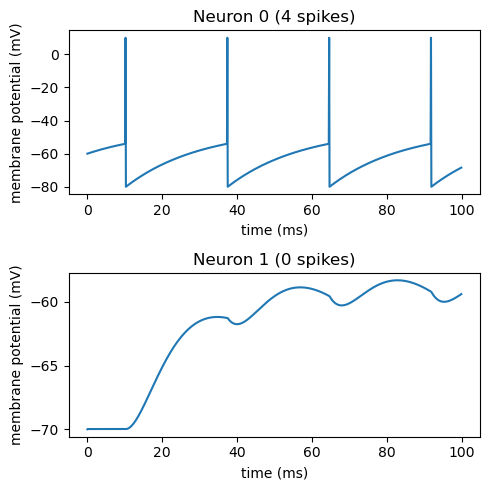

****************************************
****************************************

injected current = 1


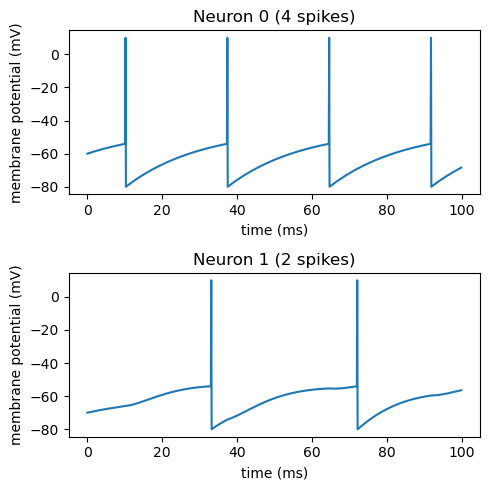

****************************************
****************************************

injected current = 10


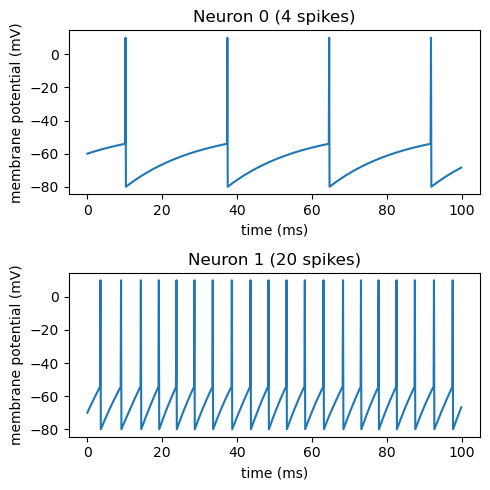

****************************************


In [6]:
for i_e_2 in [0, 1, 10]:
    print(f"****************************************")
    print(f"\ninjected current = {i_e_2}")
    sim = nsimulator(2)
    sim.set_mpotential(0, -60) 
    sim.set_mpotential(1, -70)  
    sim.set_Ie(0, 2.5) 
    sim.set_Ie(1, i_e_2) 
    sim.make_excitatory_connection(0, 1)
    sim.simulate_timeinterval(0.0, 0.1)
    sim.plot_membranepotentials([0, 1])
    print(f"****************************************")

# 1e

The results incidate that exhititory coupling leads to synchronization, and inhibitory coupling does not (as the negative feedback causes one neuron's spike to delay the other, leading to alternating spikes)! I did not observe a phase offset initially, so I had to add in the random intiialization as requested. This made a difference, and that is how I make the concludion that exhitatory couplings lead to sync, and inhibitory does not. 

Excitation + fixed initialization --> firing nearly in phase, no clear offset.

Excitation + random initalization --> synchronized, nearly in phase.

Inhibiation + fixed initialization --> each neurons spike suppressed one another. Thus, we see an offset with hyperpolarization. Thus, we see spike alternation.

Inhitibtion + random initialization --> alternating rythm, inhibition promotes spike alternation!

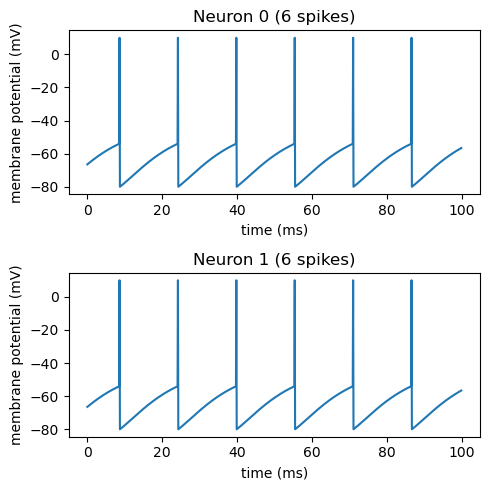

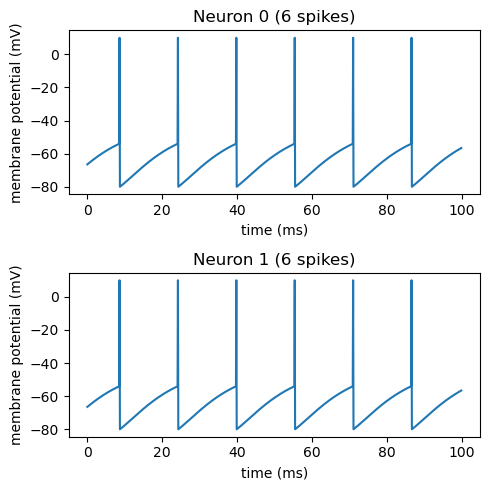

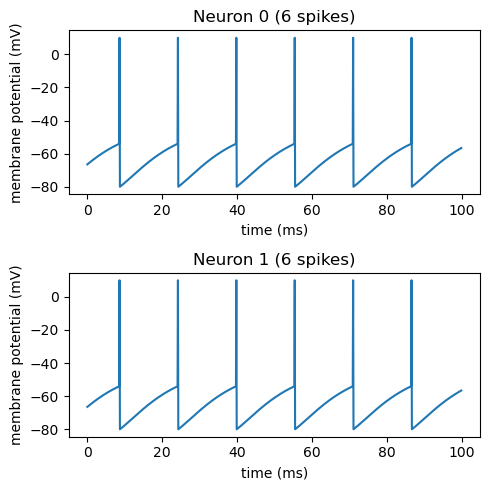

In [7]:
def run_trials(excitatory, fixed):
    for _ in range(3):
        sim = nsimulator(2)
        sim.set_Ie(0, 2.5)
        sim.set_Ie(1, 2.5)
        if fixed == True: 
            sim.set_mpotential(0, -60)
            sim.set_mpotential(1, -60)
        if excitatory == True:
            sim.make_excitatory_connection(0, 1)
            sim.make_excitatory_connection(1, 0)
        else:
            sim.make_inhibitory_connection(0, 1)
            sim.make_inhibitory_connection(1, 0)
        sim.simulate_timeinterval(1.0, 0.1)
        sim.plot_membranepotentials([0, 1])

run_trials(True, True)

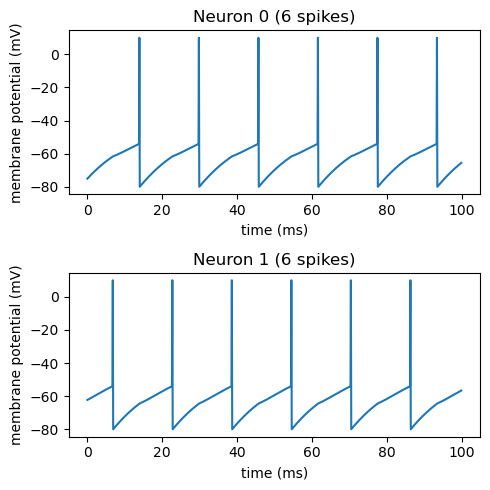

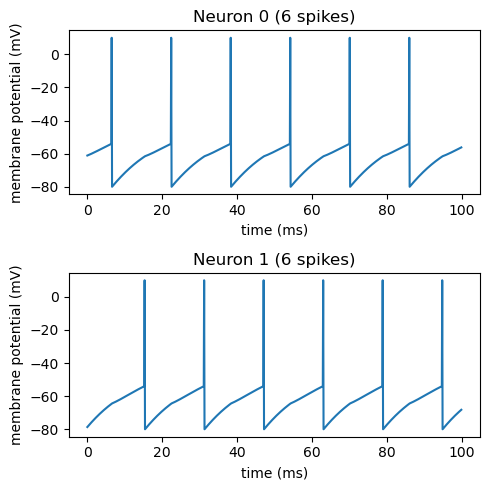

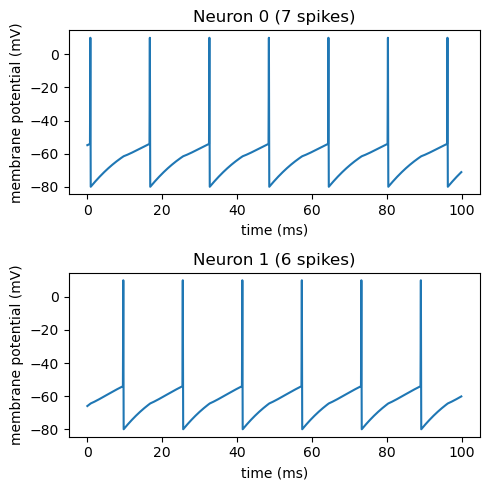

In [8]:
run_trials(True, False)


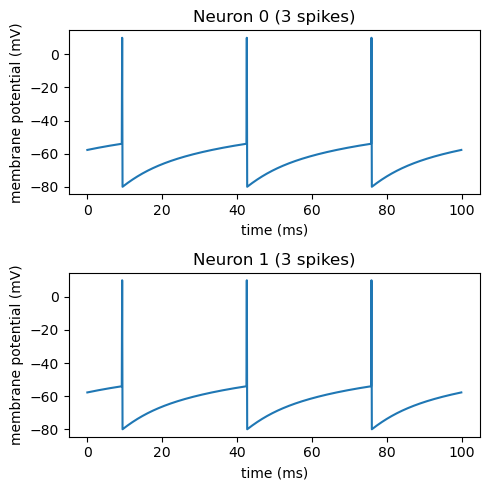

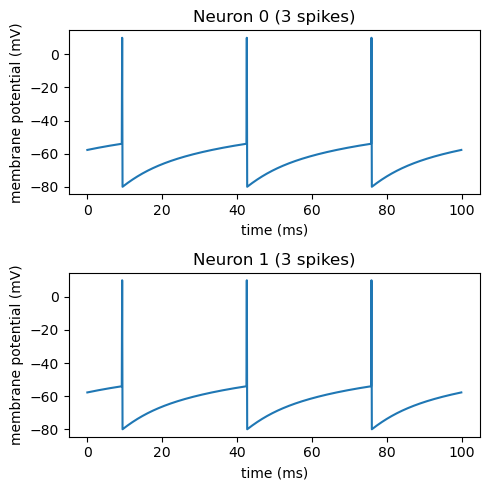

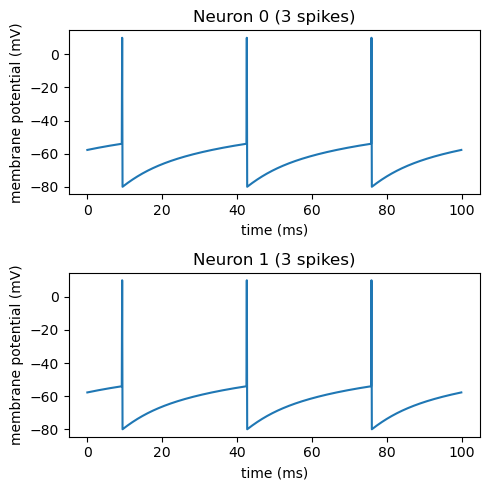

In [9]:
run_trials(False, True)

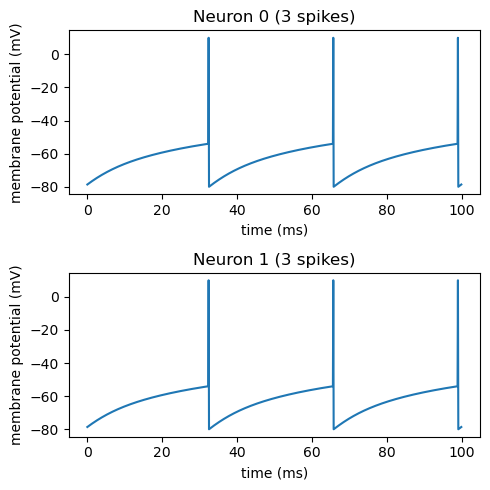

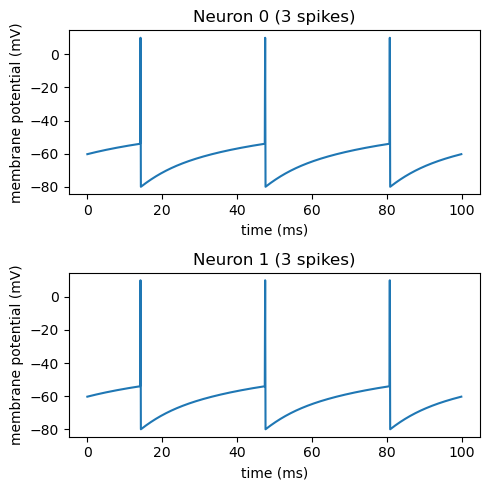

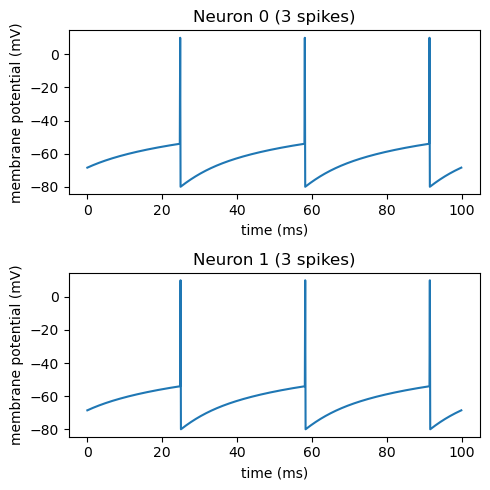

In [10]:
run_trials(False, False)


# 2d

In [ ]:
A = np.array([
    [1/3, 1/3, 1/3, 0,   0,   0],    
    [0,   0,   0,   1/3, 1/3, 1/3]
])

w = np.array([1, 2, 3, 4, 5, 6])

result = A @ w

print(result)

[2. 5.]


# 2e

In [ ]:
N = np.zeros((10,10))
a_i = -0.2 # lat influence weight
# 1 <= i <= 10
for i in range(n):
    N[i, i] = 1     
    if i > 0:     
        N[i, i-1] = a_i
    if i < n - 1: 
        N[i, i+1] = a_i
print(N)



[[ 1.  -0.2  0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.2  1.  -0.2  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.2  1.  -0.2  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.2  1.  -0.2  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -0.2  1.  -0.2  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.2  1.  -0.2  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.2  1.  -0.2  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -0.2  1.  -0.2  0. ]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.2  1.  -0.2]
 [ 0.   0.   0.   0.   0.   0.   0.   0.  -0.2  1. ]]


# 2f

The input includes a clear step 10 -> 20. Our output is a lateral inhibition network, where each sample is inhibited by immediate neighbors. This effectively suppresses uniform regions, and if we ignore the boundaries, our final output looks like so: [6.,  6.,  6.,  4., 14., 12., 12., 12.]. That looks like a pretty perfect suppression of the boundary too me, and it even resembles a mach band like pattern! Although absolute values of differences are reduced, the contrast relative to local baselines is increased which effectively makes this edge even more pronounced (mach band). Thus, our input is a clean step  from a dark band to a light band and the output represents a darker side transitioning into a lighter side with flatter lower intensity values on both sides of the output strip. The results perfectly match our expecations for the behavior of a lateral inhibitory network!

In [1]:
N = np.zeros((10,10))
a_i = -0.2 # lat influence weight
# 1 <= i <= 10
for i in range(n):
    N[i, i] = 1     
    if i > 0:     
        N[i, i-1] = a_i
    if i < n - 1: 
        N[i, i+1] = a_i

input_vector = np.array([10, 10, 10, 10, 10, 20, 20, 20, 20, 20])
network = N @ input_vector
network

NameError: name 'np' is not defined

# 2g

This network acts like a smoothing (low pass) filter by averaging neighbors which will effectively reduce contrast at rapid changes. 

In [ ]:
N = np.zeros((10,10))
a_i = 1/3 # lat influence weight
# 1 <= i <= 10
for i in range(n):
    N[i, i] = 1     
    if i > 0:     
        N[i, i-1] = a_i
    if i < n - 1: 
        N[i, i+1] = a_i

vector_1 = np.array([10,10,10,10,10,20,20,20,20,20], float)
vector_2 = np.array([10,8,10,8,10,8,10,8,10,8], float)

ffn_one = A @ vector_1
ffn_two = A @ vector_2

print(np.round(A,1))
print("lat @ ffn_one =", np.round(ffn_one,1))
print("lat @ ffn_two =", np.round(ffn_two,1))
print("interior of ffn_one:", np.round(ffn_one[1:-1],1))
print("interior of ffn_two", np.round(ffn_two[1:-1],1))


[[1.  0.3 0.  0.  0.  0.  0.  0.  0.  0. ]
 [0.3 1.  0.3 0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.3 1.  0.3 0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.3 1.  0.3 0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.3 1.  0.3 0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.3 1.  0.3 0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.3 1.  0.3 0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.3 1.  0.3 0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.3 1.  0.3]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.3 1. ]]
lat @ ffn_one = [13.3 16.7 16.7 16.7 20.  30.  33.3 33.3 33.3 26.7]
lat @ ffn_two = [12.7 14.7 15.3 14.7 15.3 14.7 15.3 14.7 15.3 11.3]
interior of ffn_one: [16.7 16.7 16.7 20.  30.  33.3 33.3 33.3]
interior of ffn_two [14.7 15.3 14.7 15.3 14.7 15.3 14.7 15.3]


# 2h

Our goal is to create a multi level feedforward model using the model in e and the output from that network as input into the layer of model g. We set up one lateral inhibitory networks connected too an excitatory neighbor averaging network. We expect the combined action of the system to create a filter that composes both edge enhacement and low pass smoothing. The combined action is a single linear map N = N_g @ N_e that performs both operations. Appling our N to the constant input produces the following: "[10.  10.7 10.  10.  10.  10.  10.  10.  10.7 10. ]". This behavior matches what we expected. The interior remains constant while the boundary shows ripples due to the finite support of the filters and zero padding at the ends.

In [ ]:
N_e = np.zeros((10,10))
a_i = -0.2 # lat influence weight
# 1 <= i <= 10
for i in range(n):
    N_e[i, i] = 1     
    if i > 0:     
        N_e[i, i-1] = a_i
    if i < n - 1: 
        N_e[i, i+1] = a_i

N_g = np.zeros((10,10))
a_i = 1/3 # lat influence weight
# 1 <= i <= 10
for i in range(n):
    N_g[i, i] = 1     
    if i > 0:     
        N_g[i, i-1] = a_i
    if i < n - 1: 
        N_g[i, i+1] = a_i

N = N_g @ N_e

# verify remark
verify = np.full(n, 10.0)
out = N @ verify

print("N_g @ N_e = \n", np.round(A, 1))
print("Input =", x)
print("Output =", np.round(out, 1))


N_g @ N_e = 
 [[ 0.9  0.1 -0.1  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.1  0.9  0.1 -0.1  0.   0.   0.   0.   0.   0. ]
 [-0.1  0.1  0.9  0.1 -0.1  0.   0.   0.   0.   0. ]
 [ 0.  -0.1  0.1  0.9  0.1 -0.1  0.   0.   0.   0. ]
 [ 0.   0.  -0.1  0.1  0.9  0.1 -0.1  0.   0.   0. ]
 [ 0.   0.   0.  -0.1  0.1  0.9  0.1 -0.1  0.   0. ]
 [ 0.   0.   0.   0.  -0.1  0.1  0.9  0.1 -0.1  0. ]
 [ 0.   0.   0.   0.   0.  -0.1  0.1  0.9  0.1 -0.1]
 [ 0.   0.   0.   0.   0.   0.  -0.1  0.1  0.9  0.1]
 [ 0.   0.   0.   0.   0.   0.   0.  -0.1  0.1  0.9]]
Input x = [10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
Output y = [10.  10.7 10.  10.  10.  10.  10.  10.  10.7 10. ]


# 3a

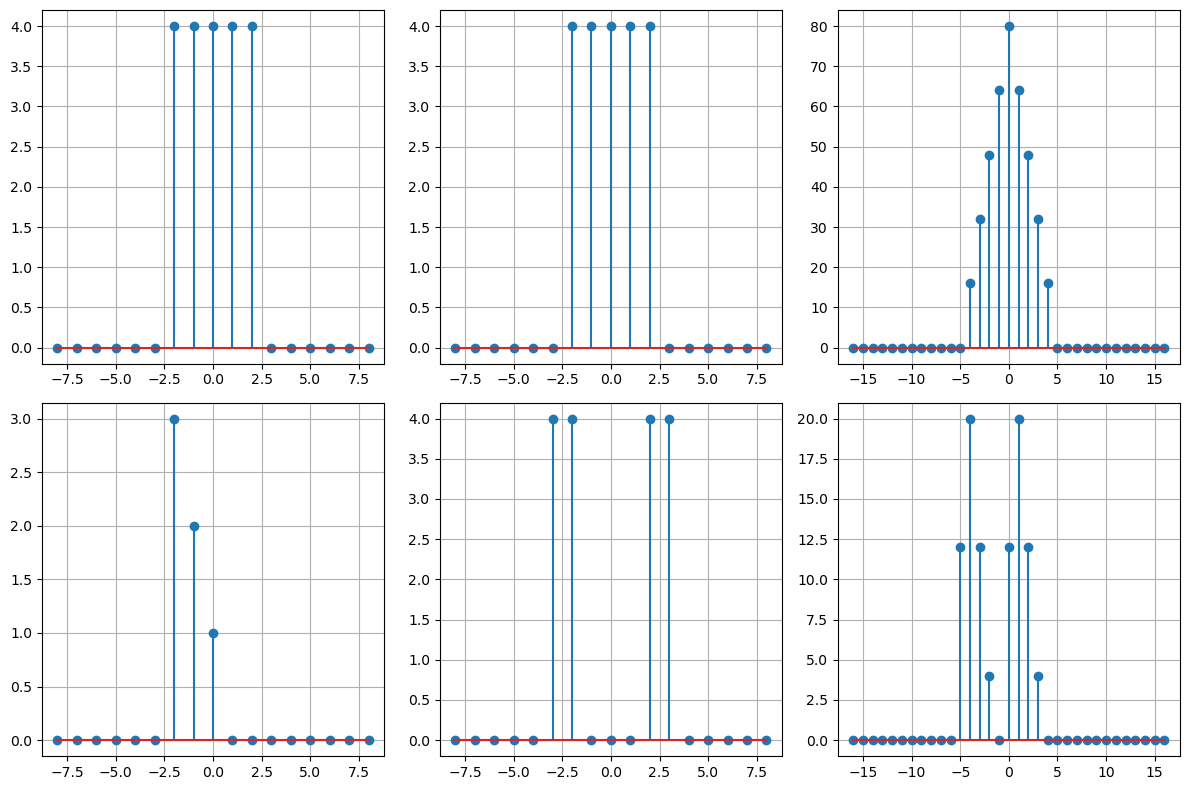

In [132]:
import matplotlib.pyplot as plt

def generate_sequence(nmin, nmax, where_to_value):
    ngrid = np.arange(nmin, nmax + 1, dtype=int)
    x = np.array([where_to_value(n) for n in ngrid], dtype=float)
    return x, ngrid

def convole(x, nx, h, nh):
    y = np.convolve(x, h, mode='full') 
    ny = np.arange(nx[0] + nh[0], nx[-1] + nh[-1] + 1, dtype=int)
    return y, ny

x1, x2 = generate_sequence(-8, 8, lambda n: 4.0 if -2 <= n <= 2 else 0.0)
x3, x4 = generate_sequence(-8, 8, lambda k: 4.0 if -2 <= k <= 2 else 0.0)
x5, x6 = convole(x1, x2, x3, x4)

x7, x8 = generate_sequence(-8, 8, lambda n: max(0.0, -n+1) if n <= 1 and n >=-2 else 0.0)
x9, x10 = generate_sequence(-8, 8, lambda k: 4.0 if abs(k) == 2 or abs(k) == 3 else 0.0)
x11, x12 = convole(x7, x8, x9, x10)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.stem(x2, x1)
plt.grid(True)
plt.subplot(2, 3, 2)
plt.stem(x4, x3)
plt.grid(True)
plt.subplot(2, 3, 3)
plt.stem(x6, x5)
plt.grid(True)
plt.subplot(2, 3, 4)
plt.stem(x8, x7)
plt.grid(True)
plt.subplot(2, 3, 5)
plt.stem(x10, x9)
plt.grid(True)
plt.subplot(2, 3, 6)
plt.stem(x12, x11)
plt.grid(True)

plt.tight_layout()
plt.show()

# 3b

In [ ]:
from scipy.signal import convolve2d

INPUT = np.array([
    [ 1,  2,  3,  4],
    [ 5,  6,  7,  8],
    [ 9, 10, 11, 12],
    [13, 14, 15, 16]
], dtype=float)

KERNEL = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=float)

# flip vertically and horizontall for true dconv
flipped_conv = KERNEL[::-1, ::-1]                     
kernel_height, kernel_width = flipped_conv.shape
height, width = INPUT.shape
out = np.zeros((height+kernel_height-1, width+kernel_width-1), float)
INPUT_padded = np.pad(INPUT, ((kernel_height-1, kernel_height-1), 
                (kernel_width-1, kernel_width-1)), mode='constant')
# convolve!
for i in range(out.shape[0]):
    for j in range(out.shape[1]): # dot product here
        out[i, j] = np.sum(INPUT_padded[i:i+kernel_height, j:j+kernel_width] * flipped_conv)

print(out)

out_verification = convolve2d(INPUT, KERNEL, mode='full', boundary='fill', fillvalue=0)
out_verification

[[ -1.  -4.  -8. -12. -11.  -4.]
 [ -5. -16. -24. -28. -23.  -8.]
 [ -8. -24. -32. -32. -24.  -8.]
 [ -8. -24. -32. -32. -24.  -8.]
 [  9.  28.  40.  44.  35.  12.]
 [ 13.  40.  56.  60.  47.  16.]]


array([[ -1.,  -4.,  -8., -12., -11.,  -4.],
       [ -5., -16., -24., -28., -23.,  -8.],
       [ -8., -24., -32., -32., -24.,  -8.],
       [ -8., -24., -32., -32., -24.,  -8.],
       [  9.,  28.,  40.,  44.,  35.,  12.],
       [ 13.,  40.,  56.,  60.,  47.,  16.]])